# 59 - 顔Embedding: Python vs JS 互換性検証

Python (InsightFace / ArcFace) で生成した顔 Embedding と、
JavaScript (onnxruntime-node) で同じ ONNX モデルを実行した結果が
**同じベクトル表現になるか** を検証する。

## 背景と目的

- **ユースケース**: Python (GPU) で事前に顔 Embedding を計算して DB に保存し、
  ブラウザ (JS) から新規画像をアップロード → 顔 Embedding → DB 検索
- **検証すべきこと**: Python と JS で同じ ONNX モデルを実行した場合に、
  Embedding が一致するか（コサイン類似度 ≈ 1.000 か）

## 2段階アプローチ

- **Phase 1**: Python でアライメント済み顔クロップ (112x112) を保存 →
  Python / JS 両方で ArcFace ONNX を実行 → Embedding を比較
- **Phase 2**: JS Embedding をクエリとして DuckDB の Python Embedding を検索し、
  検索結果が一致するか確認

In [1]:
import json
import os
import subprocess
from pathlib import Path

import cv2
import duckdb
import matplotlib.pyplot as plt
import numpy as np
import onnxruntime as ort
import pandas as pd
from IPython.display import display
from insightface.app import FaceAnalysis
from insightface.utils.face_align import norm_crop
from PIL import Image

2026-02-14 17:32:50.098697015 [W:onnxruntime:Default, device_discovery.cc:211 DiscoverDevicesForPlatform] GPU device discovery failed: device_discovery.cc:91 ReadFileContents Failed to open file: "/sys/class/drm/card0/device/vendor"


## 設定

In [2]:
DB_PATH = Path("../data/images.duckdb")
ARCFACE_ONNX = Path.home() / ".insightface/models/buffalo_l/w600k_r50.onnx"
FACE_CROP_DIR = Path("../data/face_crops_112")
FACE_CROP_DIR.mkdir(exist_ok=True)
EMBEDDING_DIM = 512

# Node.js のパス設定
NVM_NODE_BIN = Path.home() / ".nvm/versions/node/v24.13.1/bin"
os.environ["PATH"] = str(NVM_NODE_BIN) + ":" + os.environ.get("PATH", "")

JS_DIR = Path("../js")
JS_SCRIPT = JS_DIR / "embed_faces.mjs"

print(f"ArcFace ONNX: {ARCFACE_ONNX} (exists: {ARCFACE_ONNX.exists()})")
print(f"JS スクリプト: {JS_SCRIPT} (exists: {JS_SCRIPT.exists()})")

# DuckDB 接続
conn = duckdb.connect(str(DB_PATH), read_only=True)
conn.execute("LOAD vss;")

total_faces = conn.execute("SELECT COUNT(*) FROM face_detections").fetchone()[0]
print(f"DB 総顔数: {total_faces}")

ArcFace ONNX: /home/terapyon/.insightface/models/buffalo_l/w600k_r50.onnx (exists: True)
JS スクリプト: ../js/embed_faces.mjs (exists: True)
DB 総顔数: 75162


## Phase 1: 顔クロップ画像の準備

InsightFace で顔検出 → `norm_crop()` でアライメント → 112x112 PNG として保存。
テスト対象: terada 全10枚 + カンファレンス写真から20枚 (合計30枚程度の顔)。

テスト画像数: 30


,category,count
0,EuroPython2025,16
1,PyConJP2025,4
2,terada,10



InsightFace を初期化中...


Applied providers: ['CUDAExecutionProvider', 'CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}, 'CUDAExecutionProvider': {'sdpa_kernel': '0', 'use_tf32': '1', 'fuse_conv_bias': '0', 'prefer_nhwc': '0', 'tunable_op_max_tuning_duration_ms': '0', 'enable_skip_layer_norm_strict_mode': '0', 'tunable_op_tuning_enable': '0', 'tunable_op_enable': '0', 'use_ep_level_unified_stream': '0', 'device_id': '0', 'has_user_compute_stream': '0', 'gpu_external_empty_cache': '0', 'cudnn_conv_algo_search': 'EXHAUSTIVE', 'cudnn_conv1d_pad_to_nc1d': '0', 'gpu_mem_limit': '18446744073709551615', 'gpu_external_alloc': '0', 'gpu_external_free': '0', 'arena_extend_strategy': 'kNextPowerOfTwo', 'do_copy_in_default_stream': '1', 'enable_cuda_graph': '0', 'user_compute_stream': '0', 'cudnn_conv_use_max_workspace': '1'}}


find model: /home/terapyon/.insightface/models/buffalo_l/1k3d68.onnx landmark_3d_68 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CUDAExecutionProvider', 'CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}, 'CUDAExecutionProvider': {'sdpa_kernel': '0', 'use_tf32': '1', 'fuse_conv_bias': '0', 'prefer_nhwc': '0', 'tunable_op_max_tuning_duration_ms': '0', 'enable_skip_layer_norm_strict_mode': '0', 'tunable_op_tuning_enable': '0', 'tunable_op_enable': '0', 'use_ep_level_unified_stream': '0', 'device_id': '0', 'has_user_compute_stream': '0', 'gpu_external_empty_cache': '0', 'cudnn_conv_algo_search': 'EXHAUSTIVE', 'cudnn_conv1d_pad_to_nc1d': '0', 'gpu_mem_limit': '18446744073709551615', 'gpu_external_alloc': '0', 'gpu_external_free': '0', 'arena_extend_strategy': 'kNextPowerOfTwo', 'do_copy_in_default_stream': '1', 'enable_cuda_graph': '0', 'user_compute_stream': '0', 'cudnn_conv_use_max_workspace': '1'}}
find model: /home/terapyon/.insightface/models/buffalo_l/2d106det.o

Applied providers: ['CUDAExecutionProvider', 'CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}, 'CUDAExecutionProvider': {'sdpa_kernel': '0', 'use_tf32': '1', 'fuse_conv_bias': '0', 'prefer_nhwc': '0', 'tunable_op_max_tuning_duration_ms': '0', 'enable_skip_layer_norm_strict_mode': '0', 'tunable_op_tuning_enable': '0', 'tunable_op_enable': '0', 'use_ep_level_unified_stream': '0', 'device_id': '0', 'has_user_compute_stream': '0', 'gpu_external_empty_cache': '0', 'cudnn_conv_algo_search': 'EXHAUSTIVE', 'cudnn_conv1d_pad_to_nc1d': '0', 'gpu_mem_limit': '18446744073709551615', 'gpu_external_alloc': '0', 'gpu_external_free': '0', 'arena_extend_strategy': 'kNextPowerOfTwo', 'do_copy_in_default_stream': '1', 'enable_cuda_graph': '0', 'user_compute_stream': '0', 'cudnn_conv_use_max_workspace': '1'}}


find model: /home/terapyon/.insightface/models/buffalo_l/w600k_r50.onnx recognition ['None', 3, 112, 112] 127.5 127.5
set det-size: (640, 640)


/home/terapyon/dev/vibe-coding/image-vector-poc/.venv/lib/python3.13/site-packages/insightface/utils/face_align.py:23: FutureWarning: `estimate` is deprecated since version 0.26 and will be removed in version 2.2. Please use `SimilarityTransform.from_estimate` class constructor instead.
  tform.estimate(lmk, dst)



検出された顔数: 63
保存先: ../data/face_crops_112


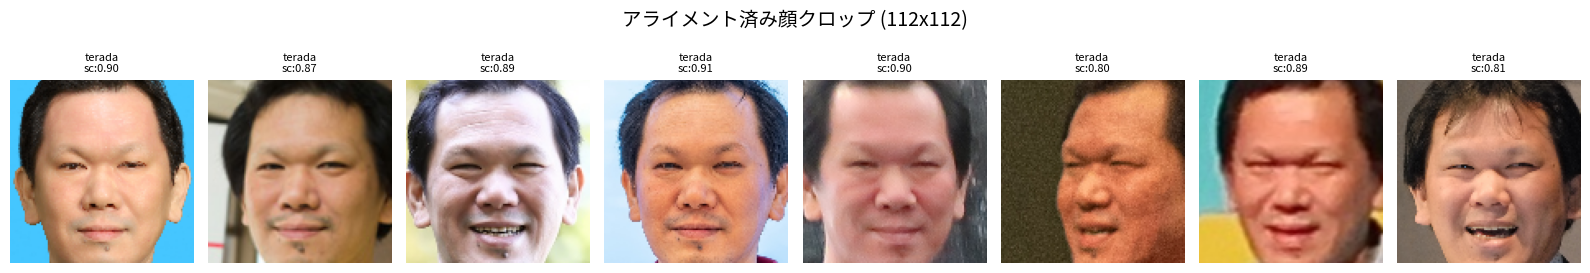

In [3]:
# テスト画像の選定
test_images = conn.execute("""
    SELECT id, file_path, file_name, category
    FROM image_catalog
    WHERE category = 'terada'
    ORDER BY file_name
""").fetchdf()

conf_images = conn.execute("""
    SELECT id, file_path, file_name, category
    FROM image_catalog
    WHERE category IN ('EuroPython2025', 'PyConJP2025')
    ORDER BY RANDOM()
    LIMIT 20
""").fetchdf()

test_images = pd.concat([test_images, conf_images], ignore_index=True)
print(f"テスト画像数: {len(test_images)}")
display(test_images.groupby("category").size().reset_index(name="count"))

# InsightFace で顔検出 + アライメント画像保存
print("\nInsightFace を初期化中...")
app = FaceAnalysis(name="buffalo_l", providers=["CUDAExecutionProvider", "CPUExecutionProvider"])
app.prepare(ctx_id=0, det_size=(640, 640))

face_crops = []  # [{"id": ..., "file_path": ..., "python_embedding": ..., "source_image": ...}]

for _, row in test_images.iterrows():
    img = cv2.imread(row["file_path"])
    if img is None:
        continue

    faces = app.get(img)
    for i, face in enumerate(faces):
        # norm_crop でアライメント済み顔画像を取得
        aligned = norm_crop(img, face.kps)
        
        # ファイル名: {image_id}_{face_index}.png
        crop_name = f"{row['id']}_{i}.png"
        crop_path = FACE_CROP_DIR / crop_name
        cv2.imwrite(str(crop_path), aligned)
        
        face_crops.append({
            "id": f"{row['id']}_{i}",
            "file_path": str(crop_path.resolve()),
            "python_embedding": face.normed_embedding.tolist(),
            "source_image": row["file_name"],
            "category": row["category"],
            "det_score": float(face.det_score),
        })

print(f"\n検出された顔数: {len(face_crops)}")
print(f"保存先: {FACE_CROP_DIR}")

# サンプル表示
fig, axes = plt.subplots(1, min(8, len(face_crops)), figsize=(16, 3))
for i, ax in enumerate(axes):
    if i < len(face_crops):
        crop = Image.open(face_crops[i]["file_path"])
        ax.imshow(crop)
        ax.set_title(f"{face_crops[i]['category'][:10]}\nsc:{face_crops[i]['det_score']:.2f}", fontsize=8)
    ax.axis("off")
plt.suptitle("アライメント済み顔クロップ (112x112)", fontsize=14)
plt.tight_layout()
plt.show()

In [4]:
# Python で ArcFace ONNX を直接実行して Embedding を取得
# (InsightFace 経由ではなく、onnxruntime で直接実行して JS と条件を揃える)

print(f"ArcFace ONNX モデルを読み込み中: {ARCFACE_ONNX}")
ort_session = ort.InferenceSession(
    str(ARCFACE_ONNX),
    providers=["CPUExecutionProvider"]  # JS と同じ CPU で実行
)

input_name = ort_session.get_inputs()[0].name
output_name = ort_session.get_outputs()[0].name
print(f"Input: {input_name}, shape: {ort_session.get_inputs()[0].shape}")
print(f"Output: {output_name}, shape: {ort_session.get_outputs()[0].shape}")

python_ort_embeddings = {}

for fc in face_crops:
    # 画像読み込み (BGR → RGB)
    img = cv2.imread(fc["file_path"])
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    # 前処理: (pixel - 127.5) / 127.5, HWC → CHW
    tensor = (img_rgb.astype(np.float32) - 127.5) / 127.5
    tensor = np.transpose(tensor, (2, 0, 1))  # CHW
    tensor = np.expand_dims(tensor, axis=0)    # (1, 3, 112, 112)
    
    # ONNX 推論
    result = ort_session.run([output_name], {input_name: tensor})
    embedding = result[0][0]
    
    # L2 正規化
    norm = np.linalg.norm(embedding)
    embedding = embedding / max(norm, 1e-8)
    
    python_ort_embeddings[fc["id"]] = embedding

print(f"\nPython ORT Embedding 計算完了: {len(python_ort_embeddings)} 顔")

# InsightFace 経由の Embedding と ORT 直接実行の Embedding を比較
print("\n--- InsightFace vs Python ORT 直接実行 ---")
insightface_vs_ort = []
for fc in face_crops:
    py_emb = np.array(fc["python_embedding"])
    ort_emb = python_ort_embeddings[fc["id"]]
    cos_sim = np.dot(py_emb, ort_emb) / (np.linalg.norm(py_emb) * np.linalg.norm(ort_emb))
    insightface_vs_ort.append(cos_sim)

insightface_vs_ort = np.array(insightface_vs_ort)
print(f"コサイン類似度: mean={insightface_vs_ort.mean():.6f}, min={insightface_vs_ort.min():.6f}, max={insightface_vs_ort.max():.6f}")
print(f"(InsightFace は GPU/CUDA で実行、ORT は CPU で実行 → 浮動小数点の差があり得る)")

ArcFace ONNX モデルを読み込み中: /home/terapyon/.insightface/models/buffalo_l/w600k_r50.onnx
Input: input.1, shape: ['None', 3, 112, 112]
Output: 683, shape: [1, 512]



Python ORT Embedding 計算完了: 63 顔

--- InsightFace vs Python ORT 直接実行 ---
コサイン類似度: mean=1.000000, min=1.000000, max=1.000000
(InsightFace は GPU/CUDA で実行、ORT は CPU で実行 → 浮動小数点の差があり得る)


## JS で同じ顔クロップに対して Embedding 生成

`embed_faces.mjs` を使い、同じ 112x112 顔クロップ画像に対して
ArcFace ONNX を `onnxruntime-node` で実行する。

In [5]:
# Face list JSON を作成
face_list_json = Path("../data/face_crops_list.json")
js_output_json = Path("../data/face_embeddings_js.json")

face_list_data = [
    {"id": fc["id"], "file_path": fc["file_path"]}
    for fc in face_crops
]

with open(face_list_json, "w") as f:
    json.dump(face_list_data, f)

print(f"Face list 保存: {face_list_json} ({len(face_list_data)} 顔)")

# JS スクリプト実行
cmd = [
    "node", str(JS_SCRIPT.resolve()),
    "--face-list", str(face_list_json.resolve()),
    "--output", str(js_output_json.resolve()),
    "--model-path", str(ARCFACE_ONNX),
]

print(f"\n実行コマンド:")
print(f"  {' '.join(cmd)}")

result = subprocess.run(cmd, capture_output=True, text=True, cwd=str(JS_DIR))
print(f"\n--- JS stderr ---")
print(result.stderr)

if result.returncode != 0:
    print(f"エラー! returncode={result.returncode}")
    print(result.stdout)
else:
    print("JS 実行完了")

Face list 保存: ../data/face_crops_list.json (63 顔)

実行コマンド:
  node /home/terapyon/dev/vibe-coding/image-vector-poc/js/embed_faces.mjs --face-list /home/terapyon/dev/vibe-coding/image-vector-poc/data/face_crops_list.json --output /home/terapyon/dev/vibe-coding/image-vector-poc/data/face_embeddings_js.json --model-path /home/terapyon/.insightface/models/buffalo_l/w600k_r50.onnx



--- JS stderr ---
Model: /home/terapyon/.insightface/models/buffalo_l/w600k_r50.onnx
Faces to process: 63
Loading ArcFace ONNX model...
Model loaded in 0.5s
Input names: input.1
Output names: 683
  [10/63] 0.4s elapsed (25.0 face/s)
  [20/63] 0.8s elapsed (25.0 face/s)
  [30/63] 1.1s elapsed (27.3 face/s)
  [40/63] 1.5s elapsed (26.7 face/s)
  [50/63] 1.9s elapsed (26.3 face/s)
  [60/63] 2.2s elapsed (27.3 face/s)
  [63/63] 2.3s elapsed (27.4 face/s)
Done. 63 embeddings saved to /home/terapyon/dev/vibe-coding/image-vector-poc/data/face_embeddings_js.json (2.3s)

JS 実行完了


In [6]:
# JS 結果の読み込み
with open(js_output_json) as f:
    js_result = json.load(f)

print(f"JS モデル: {js_result['model']}")
print(f"JS 処理数: {js_result['count']}")
print(f"JS 処理時間: {js_result['processing_time_seconds']:.1f} 秒")

# ID → embedding の辞書に変換
js_embeddings = {}
for item in js_result["embeddings"]:
    js_embeddings[item["id"]] = np.array(item["embedding"], dtype=np.float32)

print(f"JS Embedding 数: {len(js_embeddings)}")
print(f"Embedding 次元: {len(next(iter(js_embeddings.values())))}")

JS モデル: arcface/w600k_r50
JS 処理数: 63
JS 処理時間: 2.3 秒
JS Embedding 数: 63
Embedding 次元: 512


## Phase 1 結果: Python vs JS Embedding 比較

同じ 112x112 顔クロップ画像に対して:
- Python: `onnxruntime` (CPU) で ArcFace ONNX を実行
- JS: `onnxruntime-node` で同じ ArcFace ONNX を実行

コサイン類似度を計算して一致度を確認する。

In [7]:
# 1対1 コサイン類似度
cosine_sims = []
abs_diffs = []
comparison_data = []

for fc in face_crops:
    fid = fc["id"]
    py_emb = python_ort_embeddings[fid]
    js_emb = js_embeddings[fid]
    
    # コサイン類似度
    cos_sim = np.dot(py_emb, js_emb) / (np.linalg.norm(py_emb) * np.linalg.norm(js_emb))
    cosine_sims.append(cos_sim)
    
    # 絶対差
    diff = np.abs(py_emb - js_emb)
    abs_diffs.append(diff)
    
    comparison_data.append({
        "id": fid,
        "category": fc["category"],
        "source_image": fc["source_image"],
        "cosine_sim": float(cos_sim),
        "mae": float(diff.mean()),
        "max_abs_diff": float(diff.max()),
    })

cosine_sims = np.array(cosine_sims)

print("=" * 60)
print("Phase 1: Python ORT vs JS ORT — 同一顔クロップの Embedding 比較")
print("=" * 60)
print(f"\nコサイン類似度:")
print(f"  mean:   {cosine_sims.mean():.6f}")
print(f"  min:    {cosine_sims.min():.6f}")
print(f"  max:    {cosine_sims.max():.6f}")
print(f"  std:    {cosine_sims.std():.6f}")

df_comp = pd.DataFrame(comparison_data)
print(f"\n次元ごとの絶対差:")
print(f"  MAE (平均):   {df_comp['mae'].mean():.8f}")
print(f"  最大絶対差:    {df_comp['max_abs_diff'].max():.8f}")

print(f"\nカテゴリ別:")
display(df_comp.groupby("category")["cosine_sim"].agg(["mean", "min", "max"]).round(6))

Phase 1: Python ORT vs JS ORT — 同一顔クロップの Embedding 比較

コサイン類似度:
  mean:   1.000000
  min:    1.000000
  max:    1.000000
  std:    0.000000

次元ごとの絶対差:
  MAE (平均):   0.00000000
  最大絶対差:    0.00000001

カテゴリ別:


,mean,min,max
category,,,
EuroPython2025,1.0,1.0,1.0
PyConJP2025,1.0,1.0,1.0
terada,1.0,1.0,1.0


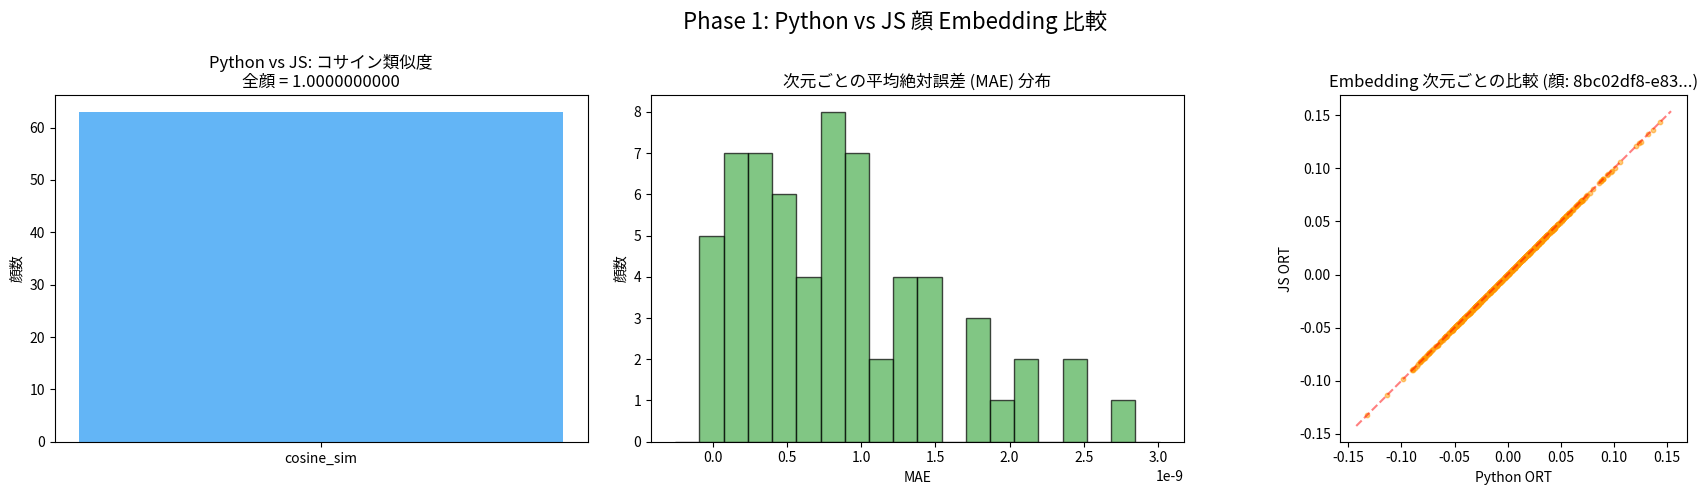

In [8]:
# 可視化
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. コサイン類似度ヒストグラム
# 値が非常に近い場合は range を手動設定
sim_min, sim_max = cosine_sims.min(), cosine_sims.max()
if sim_max - sim_min < 1e-6:
    # ほぼ全て同じ値 → バーチャートで表示
    axes[0].bar(["cosine_sim"], [len(cosine_sims)], color="#2196F3", alpha=0.7)
    axes[0].set_title(f"Python vs JS: コサイン類似度\n全顔 = {cosine_sims.mean():.10f}")
    axes[0].set_ylabel("顔数")
else:
    padding = max((sim_max - sim_min) * 0.1, 1e-6)
    axes[0].hist(cosine_sims, bins=20, edgecolor="black", alpha=0.7, color="#2196F3",
                 range=(sim_min - padding, sim_max + padding))
    axes[0].axvline(cosine_sims.mean(), color="red", linestyle="--",
                    label=f"mean={cosine_sims.mean():.6f}")
    axes[0].set_title("Python vs JS: コサイン類似度分布")
    axes[0].set_xlabel("コサイン類似度")
    axes[0].set_ylabel("顔数")
    axes[0].legend()

# 2. MAE 分布
mae_vals = df_comp["mae"].values
mae_min, mae_max = mae_vals.min(), mae_vals.max()
if mae_max - mae_min < 1e-10:
    axes[1].bar(["MAE"], [len(mae_vals)], color="#4CAF50", alpha=0.7)
    axes[1].set_title(f"MAE\n全顔 = {mae_vals.mean():.10f}")
    axes[1].set_ylabel("顔数")
else:
    padding = max((mae_max - mae_min) * 0.1, 1e-10)
    axes[1].hist(mae_vals, bins=20, edgecolor="black", alpha=0.7, color="#4CAF50",
                 range=(mae_min - padding, mae_max + padding))
    axes[1].set_title("次元ごとの平均絶対誤差 (MAE) 分布")
    axes[1].set_xlabel("MAE")
    axes[1].set_ylabel("顔数")

# 3. Python vs JS embedding の散布図 (最初の顔の全512次元)
first_id = face_crops[0]["id"]
py_first = python_ort_embeddings[first_id]
js_first = js_embeddings[first_id]
axes[2].scatter(py_first, js_first, alpha=0.5, s=10, color="#FF9800")
lim_min = min(py_first.min(), js_first.min()) - 0.01
lim_max = max(py_first.max(), js_first.max()) + 0.01
axes[2].plot([lim_min, lim_max], [lim_min, lim_max], 'r--', alpha=0.5)
axes[2].set_title(f"Embedding 次元ごとの比較 (顔: {first_id[:12]}...)")
axes[2].set_xlabel("Python ORT")
axes[2].set_ylabel("JS ORT")
axes[2].set_aspect("equal")

plt.suptitle("Phase 1: Python vs JS 顔 Embedding 比較", fontsize=16)
plt.tight_layout()
plt.show()

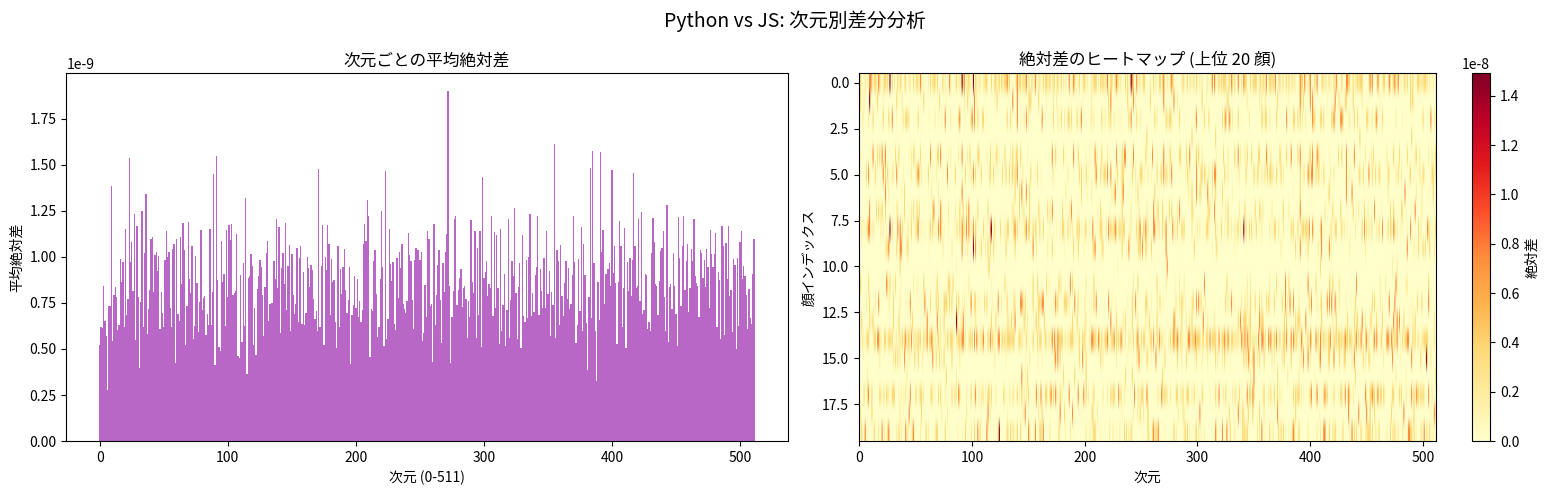

全体統計:
  全次元 MAE:          0.0000000009
  最大差異の次元:       dim 272 (diff=0.0000000019)
  最小差異の次元:       dim 6 (diff=0.0000000003)


In [9]:
# 個別次元の差分分析
all_diffs = np.stack(abs_diffs)  # shape: (N_faces, 512)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# 1. 次元ごとの平均絶対差
dim_mean_diff = all_diffs.mean(axis=0)
axes[0].bar(range(EMBEDDING_DIM), dim_mean_diff, width=1.0, color="#9C27B0", alpha=0.7)
axes[0].set_title("次元ごとの平均絶対差")
axes[0].set_xlabel("次元 (0-511)")
axes[0].set_ylabel("平均絶対差")

# 2. 差分のヒートマップ (最初の20顔)
n_show = min(20, len(all_diffs))
im = axes[1].imshow(all_diffs[:n_show, :], aspect="auto", cmap="YlOrRd")
axes[1].set_title(f"絶対差のヒートマップ (上位 {n_show} 顔)")
axes[1].set_xlabel("次元")
axes[1].set_ylabel("顔インデックス")
plt.colorbar(im, ax=axes[1], label="絶対差")

plt.suptitle("Python vs JS: 次元別差分分析", fontsize=14)
plt.tight_layout()
plt.show()

print(f"全体統計:")
print(f"  全次元 MAE:          {all_diffs.mean():.10f}")
print(f"  最大差異の次元:       dim {dim_mean_diff.argmax()} (diff={dim_mean_diff.max():.10f})")
print(f"  最小差異の次元:       dim {dim_mean_diff.argmin()} (diff={dim_mean_diff.min():.10f})")

## Phase 2: 検索互換性の検証

**実用シナリオのテスト**: JS で生成した Embedding をクエリとして、
DuckDB に保存されている Python (InsightFace) の Embedding を検索し、
結果が一致するかを確認する。

- Python Embedding でクエリした Top-10
- JS Embedding でクエリした Top-10
- ランキングの一致度を評価

In [10]:
# terada の顔をクエリとして使用
terada_crops = [fc for fc in face_crops if fc["category"] == "terada"]
print(f"terada クエリ顔数: {len(terada_crops)}")

# 各クエリで Python vs JS の検索結果を比較
K = 10
rank_matches = []

for fc in terada_crops[:5]:  # 最初の5クエリで検証
    fid = fc["id"]
    
    # Python ORT Embedding でクエリ
    py_emb = python_ort_embeddings[fid]
    py_results = conn.execute(f"""
        SELECT f.face_id, c.file_name, c.category,
               array_cosine_distance(f.embedding, ?::FLOAT[{EMBEDDING_DIM}]) as distance
        FROM face_detections f
        JOIN image_catalog c ON f.image_id = c.id
        ORDER BY distance
        LIMIT {K}
    """, [[float(x) for x in py_emb]]).fetchdf()
    
    # JS Embedding でクエリ
    js_emb = js_embeddings[fid]
    js_results = conn.execute(f"""
        SELECT f.face_id, c.file_name, c.category,
               array_cosine_distance(f.embedding, ?::FLOAT[{EMBEDDING_DIM}]) as distance
        FROM face_detections f
        JOIN image_catalog c ON f.image_id = c.id
        ORDER BY distance
        LIMIT {K}
    """, [[float(x) for x in js_emb]]).fetchdf()
    
    # ランキング一致度
    py_face_ids = py_results["face_id"].tolist()
    js_face_ids = js_results["face_id"].tolist()
    
    # Top-K 中の一致数
    overlap = len(set(py_face_ids) & set(js_face_ids))
    # 順序一致
    exact_match = py_face_ids == js_face_ids
    
    rank_matches.append({
        "query_id": fid,
        "source_image": fc["source_image"],
        "top_k_overlap": overlap,
        "overlap_ratio": overlap / K,
        "exact_rank_match": exact_match,
        "py_results": py_results,
        "js_results": js_results,
    })
    
    print(f"\nクエリ: {fc['source_image']}")
    print(f"  Top-{K} 一致数: {overlap}/{K} (順序完全一致: {exact_match})")

df_rank = pd.DataFrame([{k: v for k, v in rm.items() if k not in ('py_results', 'js_results')} 
                         for rm in rank_matches])
print(f"\n=== 検索互換性サマリー ===")
print(f"平均 Top-{K} 一致率: {df_rank['overlap_ratio'].mean():.3f}")
print(f"順序完全一致率: {df_rank['exact_rank_match'].mean():.3f}")
display(df_rank[["source_image", "top_k_overlap", "overlap_ratio", "exact_rank_match"]])

terada クエリ顔数: 10

クエリ: 202203証明写真オリジナル.jpg
  Top-10 一致数: 10/10 (順序完全一致: True)

クエリ: TeradaPyConJP.jpg
  Top-10 一致数: 10/10 (順序完全一致: True)

クエリ: terada-2020-square-500.jpg
  Top-10 一致数: 10/10 (順序完全一致: True)

クエリ: terada-202205-pyconjp-4-3-900.jpg
  Top-10 一致数: 10/10 (順序完全一致: True)

クエリ: terada-pao-2025.jpg
  Top-10 一致数: 10/10 (順序完全一致: True)

=== 検索互換性サマリー ===
平均 Top-10 一致率: 1.000
順序完全一致率: 1.000


,source_image,top_k_overlap,overlap_ratio,exact_rank_match
0,202203証明写真オリジナル.jpg,10,1.0,True
1,TeradaPyConJP.jpg,10,1.0,True
2,terada-2020-square-500.jpg,10,1.0,True
3,terada-202205-pyconjp-4-3-900.jpg,10,1.0,True
4,terada-pao-2025.jpg,10,1.0,True


In [11]:
# Python vs JS のランキング差を詳細に比較
print("Python vs JS 検索結果の詳細比較 (1つ目のクエリ):")
print()

rm = rank_matches[0]
py_r = rm["py_results"].copy()
js_r = rm["js_results"].copy()
py_r["similarity"] = 1.0 - py_r["distance"]
js_r["similarity"] = 1.0 - js_r["distance"]

print("--- Python ORT クエリ ---")
display(py_r[["file_name", "category", "similarity"]].head(K))

print("\n--- JS ORT クエリ ---")
display(js_r[["file_name", "category", "similarity"]].head(K))

# 類似度の差
if len(py_r) > 0 and len(js_r) > 0:
    print(f"\n類似度の差 (Top-1):")
    print(f"  Python: {py_r.iloc[0]['similarity']:.6f}")
    print(f"  JS:     {js_r.iloc[0]['similarity']:.6f}")
    print(f"  差:     {abs(py_r.iloc[0]['similarity'] - js_r.iloc[0]['similarity']):.8f}")

Python vs JS 検索結果の詳細比較 (1つ目のクエリ):

--- Python ORT クエリ ---


,file_name,category,similarity
0,202203証明写真オリジナル.jpg,terada,1.000000
1,2025-07-16 18.40.31.jpg,EuroPython2025,0.800413
2,2025-07-16 00.37.53.jpg,EuroPython2025,0.799080
3,terada-pao-2025.jpg,terada,0.781477
4,terada-202205-pyconjp-4-3-900.jpg,terada,0.781322
5,2025-07-18 00.31.47.jpg,EuroPython2025,0.778066
6,1000042021.jpg,PyConJP2025,0.776723
7,2025-09-27 15.33.31.jpg,PyConJP2025,0.753268
8,2025-09-27 15.23.34.jpg,PyConJP2025,0.744892
9,terada-2020-square-500.jpg,terada,0.743647



--- JS ORT クエリ ---


,file_name,category,similarity
0,202203証明写真オリジナル.jpg,terada,1.000000
1,2025-07-16 18.40.31.jpg,EuroPython2025,0.800413
2,2025-07-16 00.37.53.jpg,EuroPython2025,0.799080
3,terada-pao-2025.jpg,terada,0.781476
4,terada-202205-pyconjp-4-3-900.jpg,terada,0.781322
5,2025-07-18 00.31.47.jpg,EuroPython2025,0.778066
6,1000042021.jpg,PyConJP2025,0.776723
7,2025-09-27 15.33.31.jpg,PyConJP2025,0.753268
8,2025-09-27 15.23.34.jpg,PyConJP2025,0.744892
9,terada-2020-square-500.jpg,terada,0.743647



類似度の差 (Top-1):
  Python: 1.000000
  JS:     1.000000
  差:     0.00000000


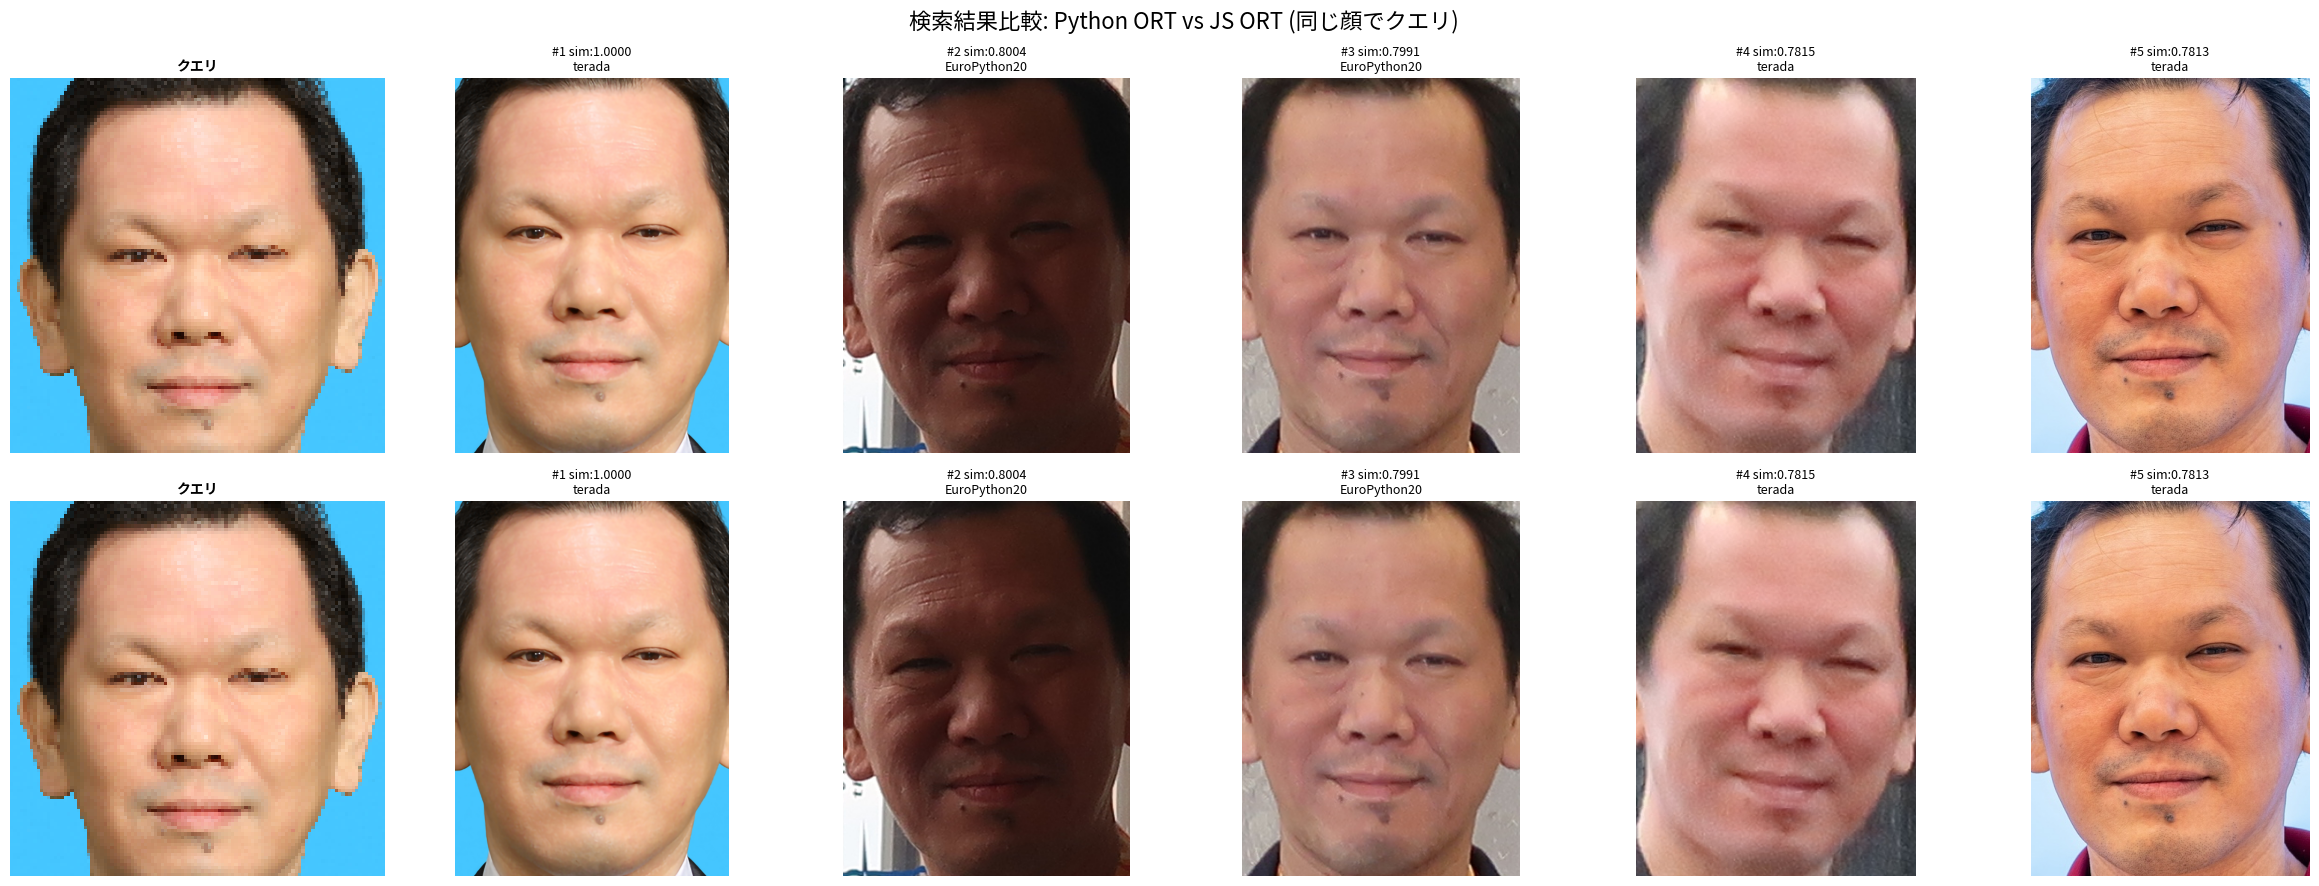

In [12]:
# サイドバイサイド可視化 (Python vs JS の Top-5)
rm = rank_matches[0]
py_r = rm["py_results"]
js_r = rm["js_results"]

fig, axes = plt.subplots(2, 6, figsize=(24, 9))

# クエリ画像 (左端)
query_path = [fc["file_path"] for fc in face_crops if fc["id"] == rm["query_id"]][0]
query_img = Image.open(query_path)

for row in range(2):
    axes[row][0].imshow(query_img)
    axes[row][0].set_title("クエリ", fontsize=10, fontweight="bold")
    axes[row][0].axis("off")

# Python Top-5
for i in range(min(5, len(py_r))):
    row = py_r.iloc[i]
    try:
        # face_detections から bbox を取得して顔クロップ
        face_info = conn.execute("""
            SELECT c.file_path, f.bbox_x1, f.bbox_y1, f.bbox_x2, f.bbox_y2
            FROM face_detections f
            JOIN image_catalog c ON f.image_id = c.id
            WHERE f.face_id = ?
        """, [row["face_id"]]).fetchone()
        
        img = Image.open(face_info[0]).convert("RGB")
        x1 = max(0, int(face_info[1]) - 10)
        y1 = max(0, int(face_info[2]) - 10)
        x2 = min(img.width, int(face_info[3]) + 10)
        y2 = min(img.height, int(face_info[4]) + 10)
        crop = img.crop((x1, y1, x2, y2))
        axes[0][i + 1].imshow(crop)
    except Exception:
        pass
    sim = 1.0 - row["distance"]
    axes[0][i + 1].set_title(f"#{i+1} sim:{sim:.4f}\n{row['category'][:12]}", fontsize=9)
    axes[0][i + 1].axis("off")

axes[0][0].set_ylabel("Python ORT", fontsize=14, rotation=0, labelpad=70, va="center")

# JS Top-5
for i in range(min(5, len(js_r))):
    row = js_r.iloc[i]
    try:
        face_info = conn.execute("""
            SELECT c.file_path, f.bbox_x1, f.bbox_y1, f.bbox_x2, f.bbox_y2
            FROM face_detections f
            JOIN image_catalog c ON f.image_id = c.id
            WHERE f.face_id = ?
        """, [row["face_id"]]).fetchone()
        
        img = Image.open(face_info[0]).convert("RGB")
        x1 = max(0, int(face_info[1]) - 10)
        y1 = max(0, int(face_info[2]) - 10)
        x2 = min(img.width, int(face_info[3]) + 10)
        y2 = min(img.height, int(face_info[4]) + 10)
        crop = img.crop((x1, y1, x2, y2))
        axes[1][i + 1].imshow(crop)
    except Exception:
        pass
    sim = 1.0 - row["distance"]
    axes[1][i + 1].set_title(f"#{i+1} sim:{sim:.4f}\n{row['category'][:12]}", fontsize=9)
    axes[1][i + 1].axis("off")

axes[1][0].set_ylabel("JS ORT", fontsize=14, rotation=0, labelpad=70, va="center")

plt.suptitle("検索結果比較: Python ORT vs JS ORT (同じ顔でクエリ)", fontsize=16)
plt.tight_layout()
plt.show()

## まとめ

In [13]:
# 結論テーブル
summary = pd.DataFrame([
    {
        "比較": "InsightFace (GPU) vs Python ORT (CPU)",
        "コサイン類似度 mean": f"{insightface_vs_ort.mean():.6f}",
        "コサイン類似度 min": f"{insightface_vs_ort.min():.6f}",
        "評価": "GPU vs CPU の浮動小数点差",
    },
    {
        "比較": "Python ORT (CPU) vs JS ORT (CPU)",
        "コサイン類似度 mean": f"{cosine_sims.mean():.6f}",
        "コサイン類似度 min": f"{cosine_sims.min():.6f}",
        "評価": "同一モデル・同一前処理の Runtime 差",
    },
])

print("=" * 70)
print("実験結果サマリー")
print("=" * 70)
display(summary)

# 検索互換性
print(f"\n検索互換性:")
print(f"  Top-{K} 平均一致率: {df_rank['overlap_ratio'].mean():.3f}")
print(f"  順序完全一致率:     {df_rank['exact_rank_match'].mean():.3f}")

# 実用性の評価
mean_sim = cosine_sims.mean()
if mean_sim > 0.999:
    verdict = "実質的に完全一致。Python で事前計算 → JS で検索は問題なく実現可能。"
elif mean_sim > 0.99:
    verdict = "極めて高い一致度。実用上問題なし。"
elif mean_sim > 0.95:
    verdict = "高い一致度だが、微小な差異あり。検索結果にほぼ影響なし。"
elif mean_sim > 0.90:
    verdict = "一定の差異あり。検索精度に軽微な影響の可能性。"
else:
    verdict = "有意な差異あり。前処理の違いを調査する必要がある。"

print(f"\n結論: {verdict}")
print(f"\n補足:")
print(f"  - ArcFace ONNX モデル: {ARCFACE_ONNX.name}")
print(f"  - Embedding 次元: {EMBEDDING_DIM}")
print(f"  - テスト顔数: {len(face_crops)}")
print(f"  - 前処理: (pixel - 127.5) / 127.5, RGB, CHW")

実験結果サマリー


,比較,コサイン類似度 mean,コサイン類似度 min,評価
0,InsightFace (GPU) vs Python ORT (CPU),1.000000,1.000000,GPU vs CPU の浮動小数点差
1,Python ORT (CPU) vs JS ORT (CPU),1.000000,1.000000,同一モデル・同一前処理の Runtime 差



検索互換性:
  Top-10 平均一致率: 1.000
  順序完全一致率:     1.000

結論: 実質的に完全一致。Python で事前計算 → JS で検索は問題なく実現可能。

補足:
  - ArcFace ONNX モデル: w600k_r50.onnx
  - Embedding 次元: 512
  - テスト顔数: 63
  - 前処理: (pixel - 127.5) / 127.5, RGB, CHW


In [14]:
conn.close()
print("完了")

完了
